In [10]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
 
np.random.seed(seed=0)

In [11]:
dt = 5e-5; T = 0.4 # (s)
nt = round(T/dt) # シミュレーションのステップ数
 
tref = 2e-3 # 不応期 (s)
tc_m = 1e-2 # 膜時定数 (s)
vrest = -60 # 静止膜電位 (mV) 
vreset = -65 # リセット電位 (mV) 
vthr = -40 # 閾値電位 (mV)
vpeak = 30 #　ピーク電位 (mV)

t = np.arange(nt)*dt*1e3 # 時間(ms)
I = 21*(t>50) - 21*(t>350) # 入力電流(に比例する値)(mV)

# 初期化
v = vreset # 膜電位の初期値
tlast = 0 # 最後のスパイクの時間を記録する変数 
v_arr = np.zeros(nt) # 膜電位を記録する配列

In [12]:
# シミュレーション
for i in tqdm(range(nt)):
    dv = (vrest - v + I[i]) / tc_m # 膜電位の変化量
    v = v + ((dt*i) > (tlast + tref))*dv*dt # 更新
    
    s = 1*(v>=vthr) # 発火の確認
    tlast = tlast*(1-s) + dt*i*s # 発火時刻の更新
    v = v*(1-s) + vpeak*s # 発火している場合ピーク電位に更新
    v_arr[i] = v  # 膜電位の値を保存
    v = v*(1-s) + vreset*s # 発火している場合に膜電位をリセット

100%|██████████████████████████████████████████████████████████████████████████| 8000/8000 [00:00<00:00, 119401.87it/s]


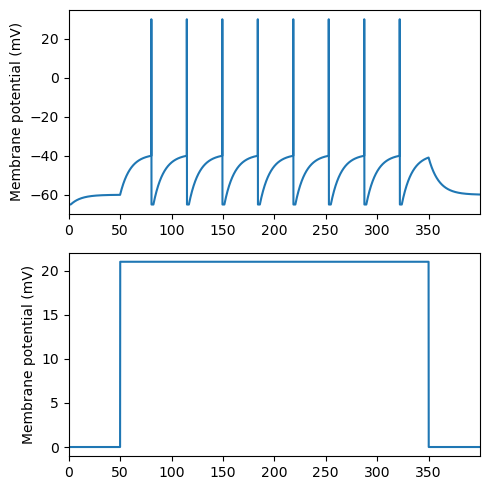

In [14]:
# 描画

plt.figure(figsize=(5, 5))
plt.subplot(2,1,1)
plt.plot(t, v_arr)
plt.ylabel('Membrane potential (mV)') 
plt.xlim(0, t.max())

plt.subplot(2,1,2)
plt.plot(t, I)
plt.ylabel('Membrane potential (mV)') 
plt.xlim(0, t.max())
plt.tight_layout()
plt.show()

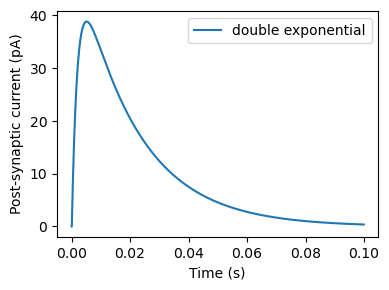

In [5]:
# -*- coding: utf-8 -*-

import numpy as np
import matplotlib.pyplot as plt
 
dt = 5e-5 # 時間ステップ (sec)
td = 2e-2 # synaptic decay time (sec)
tr = 2e-3 # synaptic rise time (sec)
T = 0.1 # シミュレーション時間 (sec)
nt = round(T/dt) #  シミュレーションの総ステップ
 
# 単一指数関数型シナプス
r = 0 # 初期値
single_r = [] #記録用配列 
for t in range(nt):    
    spike = 1 if t == 0 else 0
    single_r.append(r)
    r = r*(1-dt/td) + spike/td
    #r = r*np.exp(-dt/td) + spike/td
    
# 二重指数関数型シナプス
r = 0; hr = 0 # 初期値
double_r = [] #記録用配列
for t in range(nt):    
    spike = 1 if t == 0 else 0
    double_r.append(r)
    r = r*(1-dt/tr) + hr*dt 
    hr = hr*(1-dt/td) + spike/(tr*td)
    #r = r*np.exp(-dt/tr) + hr*dt 
    #hr = hr*np.exp(-dt/td) + spike/(tr*td)
 
# 描画
time = np.arange(nt)*dt
plt.figure(figsize=(4, 3))
plt.plot(time, np.array(double_r), label="double exponential")
plt.xlabel('Time (s)'); plt.ylabel('Post-synaptic current (pA)') 
plt.legend()
plt.tight_layout()
plt.show()


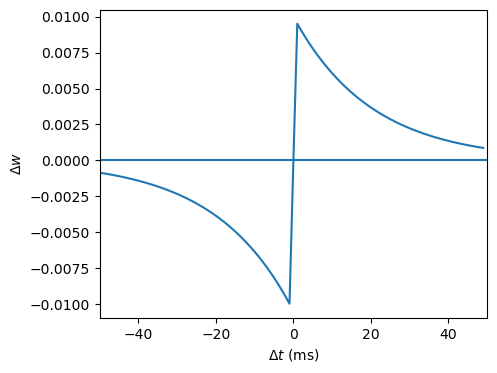

In [3]:
tau_p = tau_m = 20 #ms
A_p = 0.01
A_m = 1.05*A_p
dt = np.arange(-50, 50, 1) #ms
dw = A_p*np.exp(-dt/tau_p)*(dt>0) - A_m*np.exp(dt/tau_p)*(dt<0)
plt.figure(figsize=(5, 4))
plt.plot(dt, dw)
plt.hlines(0, -50, 50); plt.xlim(-50, 50)
plt.xlabel("$\Delta t$ (ms)"); plt.ylabel("$\Delta w$")
plt.show()

In [1]:
from brian2 import *
import numpy as np

def lif_spikes_from_timeseries(
    series_list,
    sample_dt_ms=0.1,
    tau_ms=20.0,
    resistance_mohm=100.0,
    v_rest_mV=-65.0,
    v_reset_mV=-65.0,
    v_threshold_mV=-50.0,
    refractory_ms=5.0,
):
    """
    series_list: 長さ T の 2 次元配列 (T, 2) など、各列が 1 本の時系列
    """
    defaultclock.dt = sample_dt_ms * ms

    data = TimedArray((series_list * pamp), dt=sample_dt_ms * ms)

    tau = tau_ms * ms
    R = resistance_mohm * mohm
    EL = v_rest_mV * mV
    Vreset = v_reset_mV * mV
    Vth = v_threshold_mV * mV

    eqs = '''
    dv/dt = (-(v - EL) + R * Iext) / tau : volt
    Iext = data(t, i) : amp
    '''

    n_inputs = series_list.shape[1]
    neurons = NeuronGroup(
        N=n_inputs,
        model=eqs,
        threshold='v > Vth',
        reset='v = Vreset',
        refractory=refractory_ms * ms,
        method='euler',
    )
    neurons.v = EL

    spike_mon = SpikeMonitor(neurons)
    state_mon = StateMonitor(neurons, 'v', record=True)

    runtime = len(series_list) * sample_dt_ms * ms
    run(runtime)

    return spike_mon, state_mon

if __name__ == "__main__":
    # 疑似データの例
    t_steps = 2000
    t = np.arange(t_steps) * 0.1  # ms 単位

    series_a = 200 * np.sin(2 * np.pi * t / 50) + 250  # pA
    series_b = 150 * np.cos(2 * np.pi * t / 80) + 200  # pA

    inputs = np.column_stack((series_a, series_b))

    spike_mon, state_mon = lif_spikes_from_timeseries(inputs)

    # スパイクタイミングを表示
    for neuron_idx in range(inputs.shape[1]):
        print(f"Neuron {neuron_idx}: spikes at {spike_mon.t[spike_mon.i == neuron_idx]}")


WARNING    Cannot use Cython, a test compilation failed: Microsoft Visual C++ 14.0 or greater is required. Get it with "Microsoft C++ Build Tools": https://visualstudio.microsoft.com/visual-cpp-build-tools/ (DistutilsPlatformError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]
INFO       Cannot use compiled code, falling back to the numpy code generation target. Note that this will likely be slower than using compiled code. Set the code generation to numpy manually to avoid this message:
prefs.codegen.target = "numpy" [brian2.devices.device.codegen_fallback]
WARNING    't' is an internal variable of group 'neurongroup', but also exists in the run namespace with the value array([0.000e+00, 1.000e-01, 2.000e-01, ..., 1.997e+02, 1.998e+02,
       1.999e+02]). The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


Neuron 0: spikes at [] s
Neuron 1: spikes at [] s
